<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%204/vgg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout
from sklearn.metrics import classification_report,confusion_matrix,precision_score,recall_score,f1_score
import seaborn as sns
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.utils import plot_model
import math
from tensorflow.keras.applications import VGG16
import time

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

import warnings

warnings.filterwarnings(
    "ignore",
    message="Do not pass an `input_shape`/`input_dim` argument",
    category=UserWarning
)

In [2]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
class_names=['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1682s 10us/step


In [3]:
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [4]:
X_train=X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

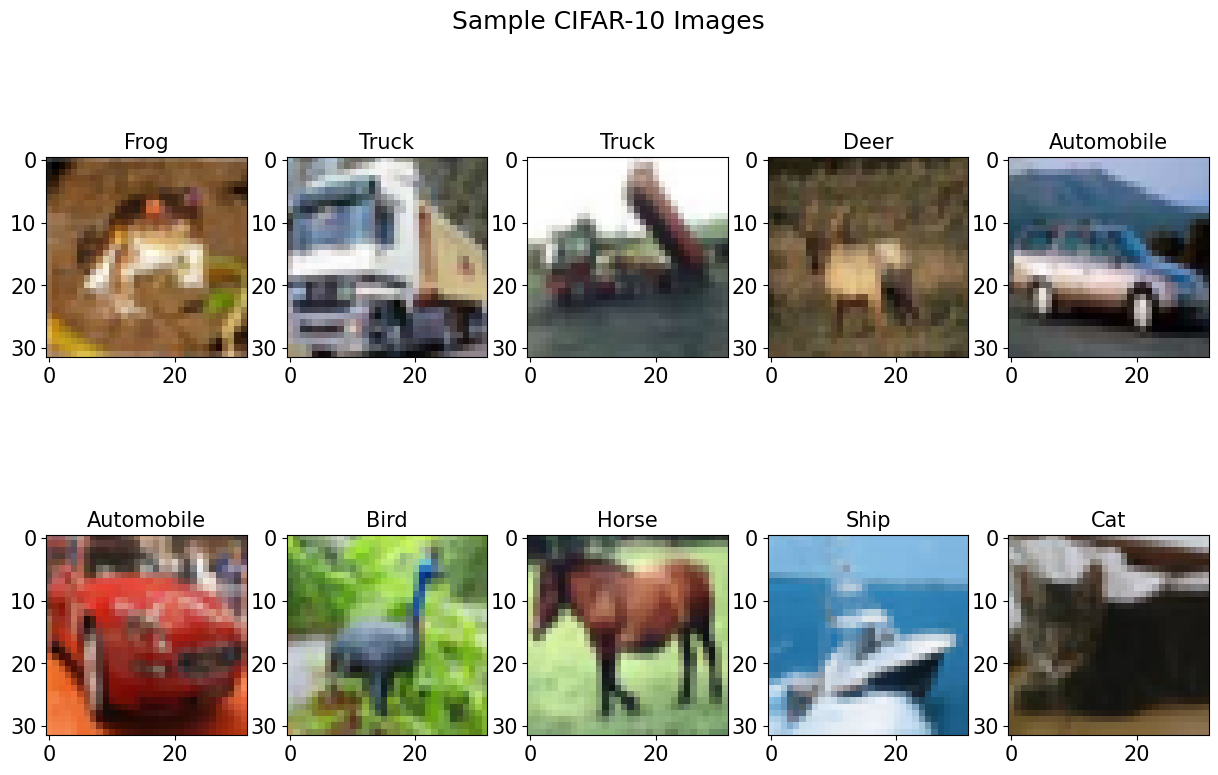

In [5]:
plt.figure(figsize=(15, 9))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])

plt.suptitle("Sample CIFAR-10 Images")
plt.savefig('sample_images.png',dpi=600)
plt.show()

In [6]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training labels after one-hot encoding:",y_train_cat.shape)

print("Testing labels after one-hot encoding:",y_test_cat.shape)

Training labels after one-hot encoding: (50000, 10)
Testing labels after one-hot encoding: (10000, 10)


In [7]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [8]:
from tensorflow.keras.layers import Resizing, GlobalAveragePooling2D

model=Sequential([
    Resizing(224, 224),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dense(10, activation="softmax")
])

model.build(input_shape=(None, 32, 32, 3))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
start_time = time.time()

In [11]:
history = model.fit(
    X_train,
    y_train_cat,
    batch_size=32,
    epochs=10,
    validation_split=0.1
)

training_time=time.time() -start_time

print("Training Time:",training_time,"seconds")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 330s 224ms/step - accuracy: 0.4630 - loss: 1.5222 - val_accuracy: 0.5444 - val_loss: 1.2893
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 316s 225ms/step - accuracy: 0.5717 - loss: 1.2205 - val_accuracy: 0.6028 - val_loss: 1.1447
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 316s 225ms/step - accuracy: 0.6050 - loss: 1.1310 - val_accuracy: 0.6056 - val_loss: 1.1231
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 316s 225ms/step - accuracy: 0.6212 - loss: 1.0813 - val_accuracy: 0.6278 - val_loss: 1.0702
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 316s 225ms/step - accuracy: 0.6350 - loss: 1.0416 - val_accuracy: 0.6128 - val_loss: 1.1006
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 316s 225ms/step - accuracy: 0.6414 - loss: 1.0180 - val_accuracy: 0.6536 - val_loss: 1.0044
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 316s 225ms/step - accuracy: 0.6518 - loss: 0.9947 - val_accuracy: 0.6590 - val_loss: 0.9889
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 316s 225ms/step - ac

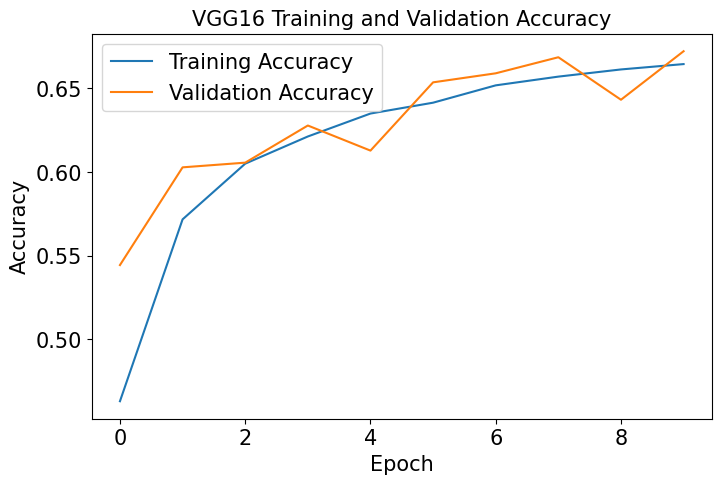

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.title("VGG16 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig('vgg_accuracy.png',dpi=600)
plt.show()

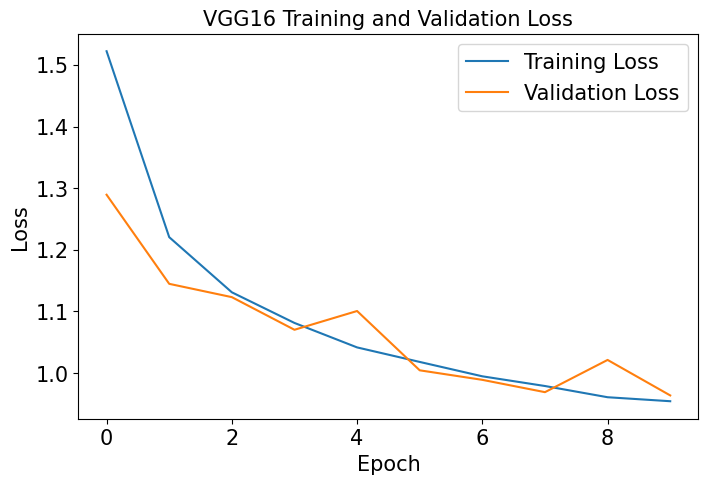

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")

plt.title("VGG16 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig('vgg_loss.png',dpi=600)
plt.show()

In [14]:
base_model.trainable=True
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-4:]:
        layer.trainable = True

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
fine_start_time = time.time()

fine_history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    batch_size=32,
    epochs=5
)

fine_training_time = (time.time()-fine_start_time)

print("Fine-tuning Time:",round(fine_training_time, 2),"seconds")

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 375s 262ms/step - accuracy: 0.6929 - loss: 0.8811 - val_accuracy: 0.7880 - val_loss: 0.6185
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 366s 260ms/step - accuracy: 0.8181 - loss: 0.5204 - val_accuracy: 0.8198 - val_loss: 0.5114
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 364s 259ms/step - accuracy: 0.8722 - loss: 0.3672 - val_accuracy: 0.8312 - val_loss: 0.5311
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 364s 259ms/step - accuracy: 0.9078 - loss: 0.2618 - val_accuracy: 0.8548 - val_loss: 0.4485
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 363s 258ms/step - accuracy: 0.9355 - loss: 0.1862 - val_accuracy: 0.8332 - val_loss: 0.5784
Fine-tuning Time: 1833.72 seconds


In [17]:
test_loss, test_accuracy=model.evaluate(X_test,y_test_cat,batch_size=32)

print("Test Accuracy:",test_accuracy*100,"%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 234ms/step - accuracy: 0.8312 - loss: 0.5945
Test Accuracy: 83.12000036239624 %


In [18]:
y_pred_prob = model.predict(X_test,batch_size=32)
y_pred = np.argmax(y_pred_prob,axis=1)
y_true = y_test.flatten()
precision = precision_score(y_true,y_pred,average="weighted")
recall = recall_score(y_true,y_pred,average="weighted")
f1 = f1_score(y_true,y_pred,average="weighted")

print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 204ms/step
Precision: 0.8443260191668606
Recall   : 0.8312
F1-score : 0.8334964227354165


In [19]:
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.90      0.82      0.86      1000
  Automobile       0.95      0.90      0.92      1000
        Bird       0.76      0.82      0.79      1000
         Cat       0.71      0.67      0.69      1000
        Deer       0.63      0.93      0.76      1000
         Dog       0.82      0.74      0.78      1000
        Frog       0.87      0.90      0.88      1000
       Horse       0.90      0.82      0.86      1000
        Ship       0.97      0.84      0.90      1000
       Truck       0.93      0.87      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



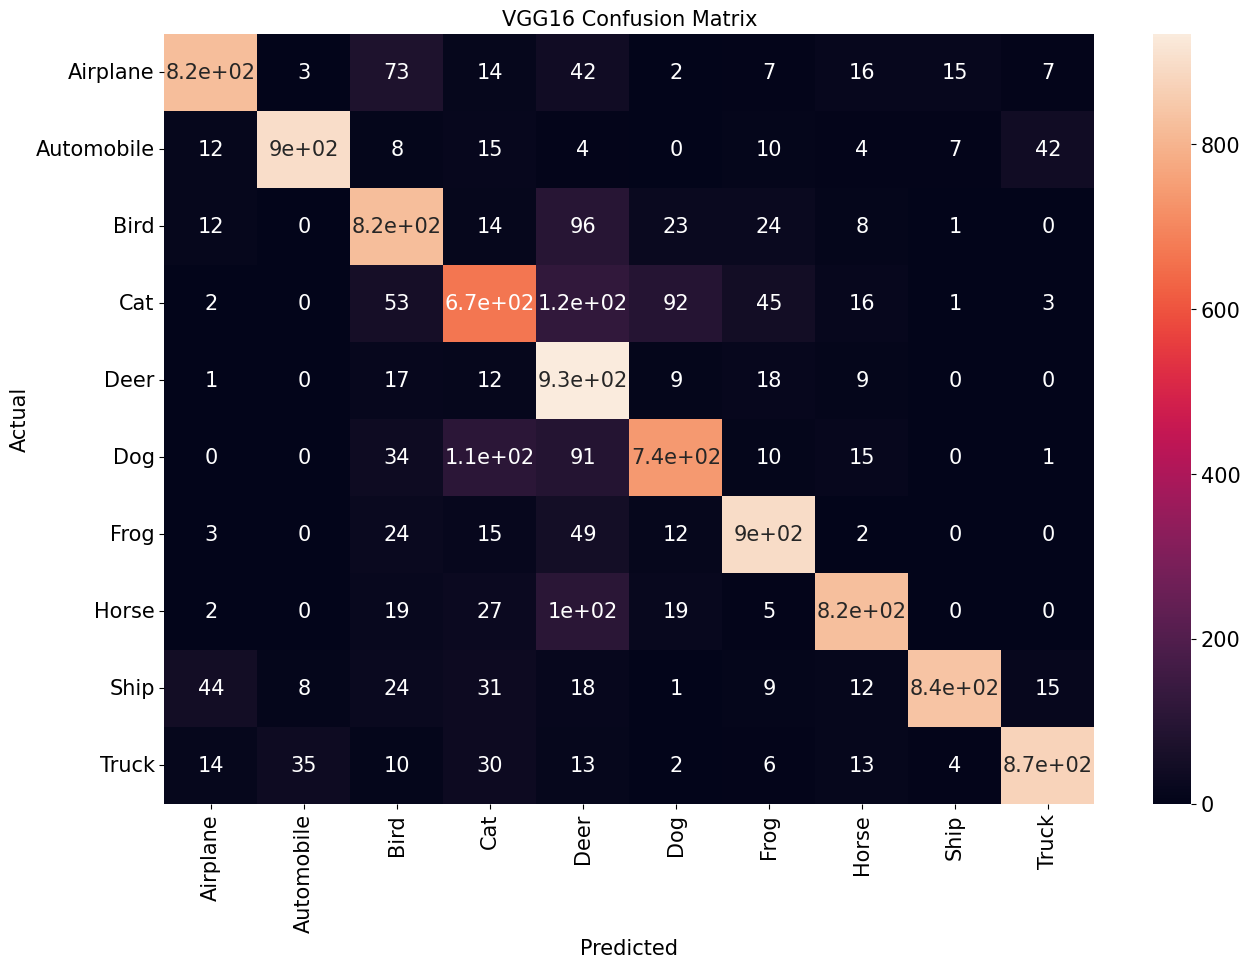

In [20]:
cm =confusion_matrix(y_true,y_pred)
plt.figure(figsize=(15, 10))
sns.heatmap(cm,annot=True,xticklabels=class_names,yticklabels=class_names)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('vgg_confusion_matrix.png',dpi=600)
plt.show()

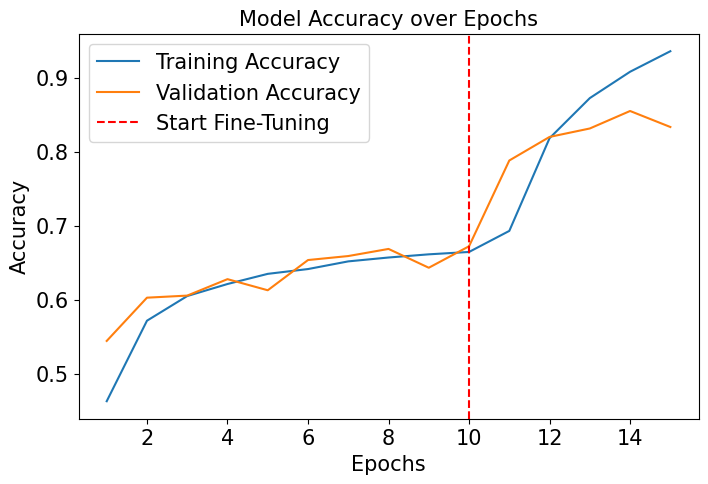

In [22]:
import matplotlib.pyplot as plt

acc = history.history['accuracy'] + fine_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_history.history['val_accuracy']

epochs = range(1, len(acc) + 1)
fine_tune_start = len(history.history['accuracy'])

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc,label='Validation Accuracy')
plt.axvline(x=fine_tune_start, color='red', linestyle='--', label='Start Fine-Tuning')

plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.show()

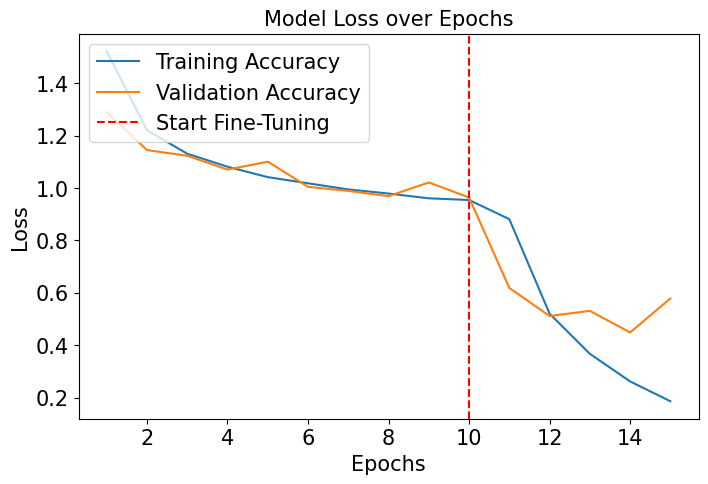

In [23]:
loss = history.history['loss'] + fine_history.history['loss']
val_loss = history.history['val_loss'] + fine_history.history['val_loss']

epochs = range(1, len(acc) + 1)
fine_tune_start = len(history.history['loss'])

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Accuracy')
plt.plot(epochs, val_loss, label='Validation Accuracy')
plt.axvline(x=fine_tune_start, color='red', linestyle='--', label='Start Fine-Tuning')

plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper left')
plt.show()